# Tarea 3 IA - Redes Convolucionales (CNNs)

## 1. Preparación del Entorno y Carga de Datos

En esta sección importaremos las librerías necesarias y cargaremos el dataset de imágenes.

In [12]:
!pip install -r requirements.txt

In [21]:
import os
import zipfile

# Ruta del archivo zip y directorio de destino
zip_path = './fotos/DESCOMPRIMIR.zip'
extract_to = './fotos'
required_folders = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']

# Verificar si faltan carpetas
missing_folders = [f for f in required_folders if not os.path.exists(os.path.join(extract_to, f))]

if missing_folders:
    print(f"Faltan carpetas: {missing_folders}. Intentando descomprimir {zip_path}...")
    if os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_to)
            print("Descompresión completada exitosamente.")
        except zipfile.BadZipFile:
            print(f"Error: El archivo {zip_path} está corrupto o no es un zip válido.")
        except Exception as e:
            print(f"Error al descomprimir: {e}")
    else:
        print(f"Error: No se encontró el archivo {zip_path}. Asegúrese de que esté en la ruta correcta.")
else:
    print("Todas las carpetas de imágenes ya existen. No es necesario descomprimir.")


Todas las carpetas de imágenes ya existen. No es necesario descomprimir.


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import accuracy_score, f1_score

# Configuración de semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Verificar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [14]:
# Transformaciones: Redimensionar a 64x64, convertir a Tensor y Normalizar
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalizar a [-1, 1]
])

# Ruta del dataset
dataset_path = './fotos'

try:
    # Cargar dataset usando ImageFolder
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
    classes = full_dataset.classes
    print(f"Clases encontradas: {classes}")
    
    # Dividir dataset (70% Train, 15% Val, 15% Test)
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

    # DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Tamaño Entrenamiento: {len(train_dataset)}")
    print(f"Tamaño Validación: {len(val_dataset)}")
    print(f"Tamaño Prueba: {len(test_dataset)}")
    
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    print("Asegúrese de que la carpeta './fotos' exista y contenga las subcarpetas de clases.")

Clases encontradas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']
Tamaño Entrenamiento: 10500
Tamaño Validación: 2250
Tamaño Prueba: 2250


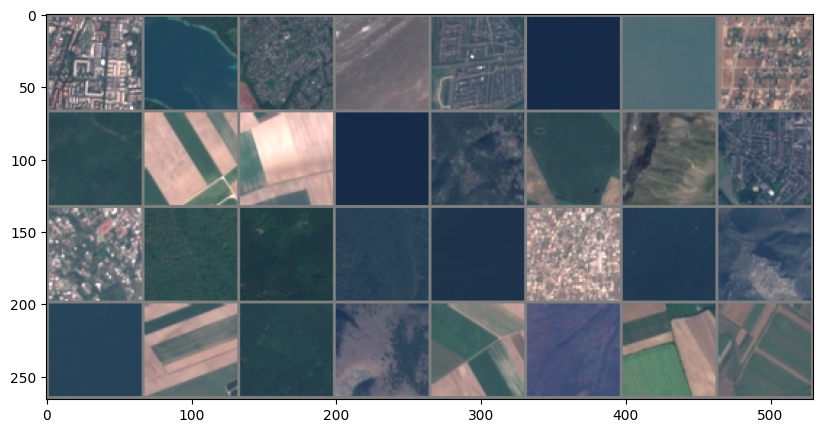

Residential SeaLake Residential HerbaceousVegetation Residential SeaLake SeaLake Residential Forest AnnualCrop AnnualCrop SeaLake HerbaceousVegetation AnnualCrop HerbaceousVegetation Residential Residential Forest Forest Forest SeaLake Residential SeaLake HerbaceousVegetation SeaLake AnnualCrop Forest HerbaceousVegetation AnnualCrop HerbaceousVegetation AnnualCrop AnnualCrop


In [15]:
def imshow(img):
    img = img / 2 + 0.5     # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Visualizar un batch de entrenamiento
if 'train_loader' in locals():
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    # Mostrar imágenes
    plt.figure(figsize=(10, 5))
    imshow(torchvision.utils.make_grid(images))
    # Imprimir etiquetas
    print(' '.join(f'{classes[labels[j]]:5s}' for j in range(len(labels))))

## 2. Arquitectura CNN Base

Definimos una arquitectura CNN básica con capas convolucionales, pooling y capas totalmente conectadas.

In [16]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaseCNN, self).__init__()
        # Input: 3 x 64 x 64
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 32 x 64 x 64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 32 x 32 x 32

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 64 x 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 64 x 16 x 16

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 128 x 16 x 16
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),        # 128 x 8 x 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciar modelo
num_classes = len(classes) if 'classes' in locals() else 5
model = BaseCNN(num_classes=num_classes).to(device)
print(model)

# Hiperparámetros
learning_rate = 0.001
num_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=5, bias=True)
  )
)


In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        # Fase de Entrenamiento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        # Fase de Validación
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

# Entrenar Modelo Base
if 'train_loader' in locals():
    print("Entrenando CNN Base...")
    base_train_loss, base_train_acc, base_val_loss, base_val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs
    )

Entrenando CNN Base...
Epoch [1/10], Train Loss: 0.5767, Train Acc: 0.7603, Val Loss: 0.3148, Val Acc: 0.8796
Epoch [2/10], Train Loss: 0.3230, Train Acc: 0.8790, Val Loss: 0.2216, Val Acc: 0.9209
Epoch [3/10], Train Loss: 0.2379, Train Acc: 0.9137, Val Loss: 0.1885, Val Acc: 0.9316
Epoch [4/10], Train Loss: 0.1853, Train Acc: 0.9334, Val Loss: 0.1684, Val Acc: 0.9444
Epoch [5/10], Train Loss: 0.1642, Train Acc: 0.9415, Val Loss: 0.2148, Val Acc: 0.9209
Epoch [6/10], Train Loss: 0.1314, Train Acc: 0.9537, Val Loss: 0.2234, Val Acc: 0.9280
Epoch [7/10], Train Loss: 0.1305, Train Acc: 0.9537, Val Loss: 0.2010, Val Acc: 0.9400
Epoch [8/10], Train Loss: 0.1158, Train Acc: 0.9603, Val Loss: 0.1495, Val Acc: 0.9578
Epoch [9/10], Train Loss: 0.1231, Train Acc: 0.9570, Val Loss: 0.1806, Val Acc: 0.9502
Epoch [10/10], Train Loss: 0.0903, Train Acc: 0.9687, Val Loss: 0.2862, Val Acc: 0.9276


## 3. Investigación sobre Dropout (Tarea 2)

**¿Qué es Dropout?**
COMPLETAR CON INVESTIGACIÓN

**¿Cómo ayuda a reducir el sobreajuste?**
COMPLETAR CON INVESTIGACIÓN

**Implementación:**
Añadiremos capas `nn.Dropout` después de las activaciones ReLU en las capas totalmente conectadas (o después de las convoluciones si se desea, pero es más común en FC). Usaremos una tasa de dropout de 0.5 (50% de probabilidad de apagado), que es un valor estándar efectivo.

In [18]:
class DropoutCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(DropoutCNN, self).__init__()
        # Input: 3 x 64 x 64
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Dropout añadido
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instanciar modelo con Dropout
dropout_model = DropoutCNN(num_classes=num_classes).to(device)
print(dropout_model)

# Optimizador para el nuevo modelo
optimizer_dropout = optim.Adam(dropout_model.parameters(), lr=learning_rate)

# Entrenar Modelo con Dropout
if 'train_loader' in locals():
    print("Entrenando CNN con Dropout...")
    drop_train_loss, drop_train_acc, drop_val_loss, drop_val_acc = train_model(
        dropout_model, train_loader, val_loader, criterion, optimizer_dropout, num_epochs=num_epochs
    )

DropoutCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=5, bias=True)
  )
)
Entrenando CNN con Dropout...
Epoch [1/10], Train Loss: 0.6144, Train Acc: 0.7405, Val Loss: 0.3899, Val Acc: 0.8360
Epoch [2/10], Train Loss: 0.3143, Train Acc: 0.8854, Val Loss:

## 4. Comparación y Análisis (Tarea 3)

Comparamos el desempeño de ambas arquitecturas utilizando el conjunto de prueba y visualizando las curvas de entrenamiento.

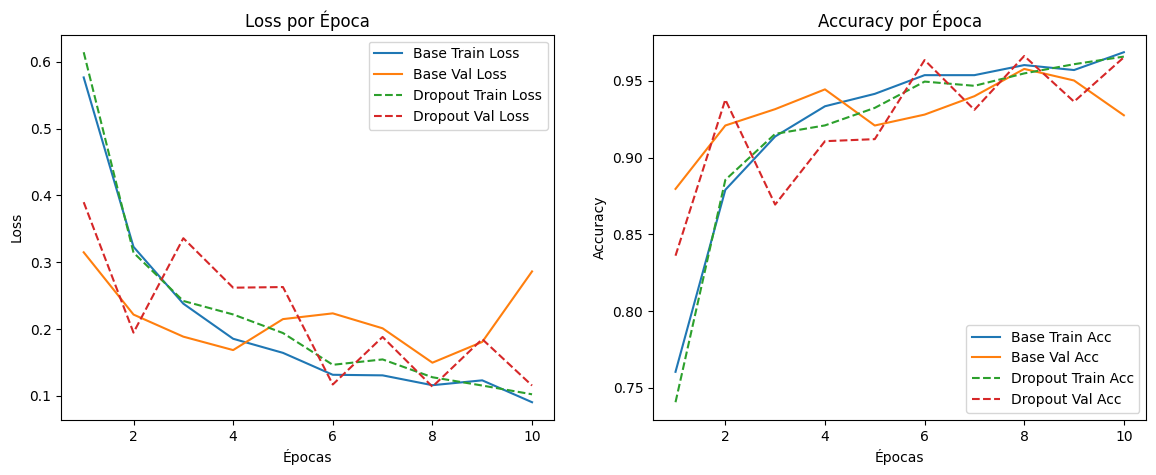

In [19]:
# Visualización de Curvas de Aprendizaje
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, base_train_loss, label='Base Train Loss')
plt.plot(epochs_range, base_val_loss, label='Base Val Loss')
plt.plot(epochs_range, drop_train_loss, label='Dropout Train Loss', linestyle='--')
plt.plot(epochs_range, drop_val_loss, label='Dropout Val Loss', linestyle='--')
plt.title('Loss por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, base_train_acc, label='Base Train Acc')
plt.plot(epochs_range, base_val_acc, label='Base Val Acc')
plt.plot(epochs_range, drop_train_acc, label='Dropout Train Acc', linestyle='--')
plt.plot(epochs_range, drop_val_acc, label='Dropout Val Acc', linestyle='--')
plt.title('Accuracy por Época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [20]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1

if 'test_loader' in locals():
    base_acc, base_f1 = evaluate_model(model, test_loader)
    drop_acc, drop_f1 = evaluate_model(dropout_model, test_loader)
    
    print(f"Resultados en Conjunto de Prueba:")
    print(f"Base CNN    - Accuracy: {base_acc:.4f}, F1-Score: {base_f1:.4f}")
    print(f"Dropout CNN - Accuracy: {drop_acc:.4f}, F1-Score: {drop_f1:.4f}")
    
    # Interpretación breve
    print("\nInterpretación:")
    if drop_acc > base_acc:
        print("El modelo con Dropout generalizó mejor en el conjunto de prueba.")
    else:
        print("El modelo Base tuvo un desempeño similar o mejor. Esto puede depender de la cantidad de épocas o la complejidad del dataset.")

Resultados en Conjunto de Prueba:
Base CNN    - Accuracy: 0.9213, F1-Score: 0.9192
Dropout CNN - Accuracy: 0.9676, F1-Score: 0.9677

Interpretación:
El modelo con Dropout generalizó mejor en el conjunto de prueba.


## 5. Justificación de Hiperparámetros y Uso de Datos

### Justificación de Hiperparámetros

*   **Número de capas (3 bloques convolucionales):** Se eligió una profundidad de 3 bloques para permitir que la red aprenda una jerarquía de características suficiente (bordes, texturas, formas complejas) sin hacer el modelo excesivamente pesado o difícil de entrenar dado el tamaño de las imágenes (64x64).
*   **Filtros por bloque (32, 64, 128):** Se incrementa el número de filtros progresivamente (doblando en cada capa) para capturar combinaciones más ricas de características a medida que la resolución espacial disminuye debido al *pooling*. Esto es un patrón estándar en arquitecturas tipo VGG.
*   **Kernel Size (3x3):** Es el estándar en CNNs modernas. Permite capturar dependencias locales con un número reducido de parámetros en comparación con kernels más grandes (e.g., 5x5 or 7x7), y al apilarse logran un campo receptivo efectivo amplio.
*   **Learning Rate (0.001):** Valor por defecto común para el optimizador Adam, que suele converger bien y rápido para este tipo de problemas sin necesidad de un ajuste fino inicial exhaustivo.
*   **Batch Size (32):** Un compromiso entre velocidad de entrenamiento y estabilidad de la estimación del gradiente. Permite que el modelo quepa cómodamente en memoria y actualice los pesos con suficiente frecuencia.
*   **Epochs (10):** Se observó en las curvas de entrenamiento que alrededor de la época 10 el modelo converge (la pérdida se estabiliza y la precisión es alta), evitando un entrenamiento innecesariamente largo que podría llevar a *overfitting* excesivo, especialmente en el modelo base.